<a href="https://colab.research.google.com/github/marmalux/Telecom-X-Machine-Learning/blob/main/Churn_de_clientes_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predición de cancelación de churn de clientes Telecom X

## Importar bibliotecas - general

In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Importar datos

Se importaran datos del proyecto de anáslisis de Telecom X los cuales ya estan limpiados para poder iniciar con la etapa de tratar datos pero para el modelo predictivo.

Además se elimina la columna ID

In [34]:
url_api ="https://github.com/marmalux/Telecom-X-Machine-Learning/raw/refs/heads/main/datos_tratados_Telecom_X.csv"

datos = pd.read_csv(url_api)
datos = datos.drop(['customerID'],axis=1)
datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total,Charges_Day,Services_Number
0,0,Female,0,1,1,9,1,No,DSL,No,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,2


## Correlación  

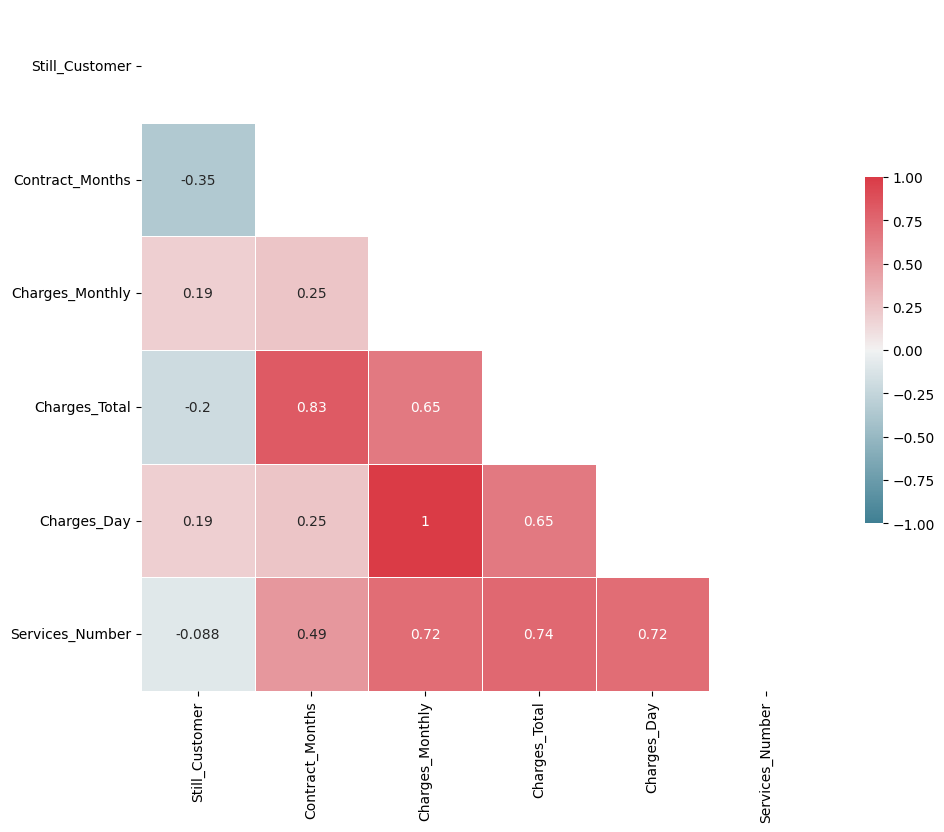

In [36]:
corr = datos[['Still_Customer','Contract_Months','Charges_Monthly','Charges_Total','Charges_Day','Services_Number']].corr()

# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

plt.show()

A partir de esta pequeña correlacion se puede ver que las columnas 'Charges_Monthly', 'Charges_Day', 'Charges_Total' tienen una relacion mas directa que pueden perjudicar al modelo por lo que solo se deja uno de ellos, además, 'Services_Number' tambien puede perjudicar al modelo pues surge a partir de los servicios mostrados, por lo que tambien se elimina

In [37]:
datos = datos.drop(['Charges_Monthly','Charges_Day','Services_Number'], axis=1)
datos.head(4)

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,593.30
1,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,542.40
2,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,280.85
3,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,1237.85


### Mapear datos para modelo

Columnas como 'Online_Security'tiene un valor extra 'No internet service' que no se necesita debido a que esto depende mas de la columna 'Internet_Service' asi que se puede quitar este valor para dejarlo como 'Yes' y 'No' para intentar mejorar el modelo

In [40]:
columnas = ['Internet_Service', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies','Multiple_Lines',
            'Still_Customer','Partner', 'Dependents', 'Phone_Service','Paperless_Billing']

# se usan columnas que tengan mas que 'yes' y 'no'
for columna in columnas:
  datos[columna] = datos[columna].replace('No internet service','No')
  datos[columna] = datos[columna].map({'Yes':1,'No':0})
  datos[columna] = datos[columna].astype(bool)
datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,True,Female,0,True,True,9,True,True,True,True,True,True,True,True,True,One year,True,Mailed check,593.30
1,True,Male,0,True,True,9,True,True,True,True,True,True,True,True,True,Month-to-month,True,Mailed check,542.40
2,True,Male,0,True,True,4,True,True,True,True,True,True,True,True,True,Month-to-month,True,Electronic check,280.85
3,True,Male,1,True,True,13,True,True,True,True,True,True,True,True,True,Month-to-month,True,Electronic check,1237.85
4,True,Female,1,True,True,3,True,True,True,True,True,True,True,True,True,Month-to-month,True,Mailed check,267.40


In [39]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Still_Customer     7043 non-null   bool   
 1   Gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   bool   
 4   Dependents         7043 non-null   bool   
 5   Contract_Months    7043 non-null   int64  
 6   Phone_Service      7043 non-null   bool   
 7   Multiple_Lines     7043 non-null   bool   
 8   Internet_Service   7043 non-null   bool   
 9   Online_Security    7043 non-null   bool   
 10  Online_Backup      7043 non-null   bool   
 11  Device_Protection  7043 non-null   bool   
 12  Tech_Support       7043 non-null   bool   
 13  Streaming_TV       7043 non-null   bool   
 14  Streaming_Movies   7043 non-null   bool   
 15  Contract_type      7043 non-null   object 
 16  Paperless_Billing  7043 